<h2>Exercise 01: Line chart with styles</h2>

In [1]:
import pandas as pd 
import sqlite3

### 1. Analyze only the users, not the admins. Analyze only the dates when there were both views and checker commits.

In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [3]:
df = pd.io.sql.read_sql(
    """
    SELECT 
       *
    FROM checker
    """,
    conn
)
df

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,NaN,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1
2,2,checking,0,2020-04-16 21:46:47.769088,7,NaN,admin_1
3,3,ready,0,2020-04-16 21:46:48.121217,7,lab02,admin_1
4,4,checking,0,2020-04-16 21:53:01.862637,6,code_rvw,admin_1
...,...,...,...,...,...,...,...
3397,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3398,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3399,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3400,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [4]:
df = pd.io.sql.read_sql(
    """
    SELECT 
        DATE(p.datetime) as date,
        COUNT(DISTINCT p.datetime) as views,
        COUNT(DISTINCT c.timestamp) as commits

    FROM pageviews p
    INNER JOIN checker c ON DATE(p.datetime) = DATE(c.timestamp) 
    WHERE p.uid LIKE "user_%" 
        AND c.uid LIKE "user_%"
    GROUP BY date
    ORDER BY date
    """,
    conn
)
df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


In [5]:
df = df.set_index('date')

### 2. Vizualization

```The font size should be 8.```

```The size of the figure should be (15, 8).```

<Axes: title={'center': 'Views and commits per day'}, xlabel='date'>

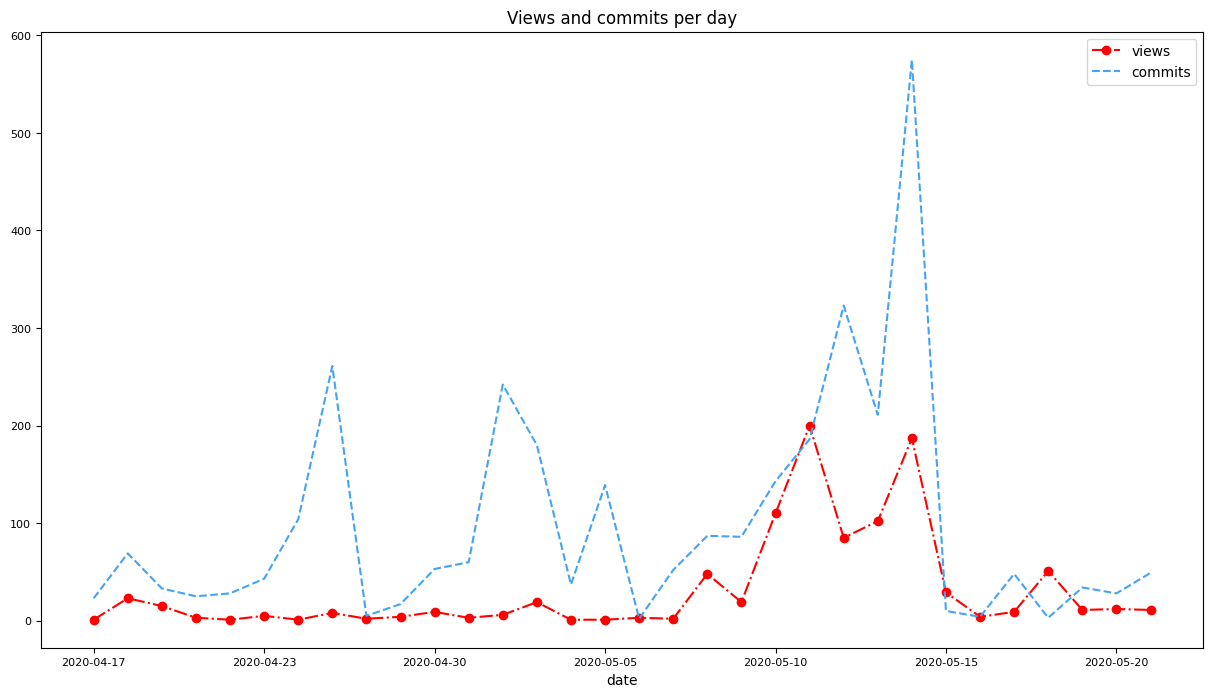

In [6]:
df.plot(
    fontsize=8,
    figsize=(15,8),
    title="Views and commits per day",
    style=["-.o", "--"],
    color=["red","#43A3F6"],
    
)
 

<h2>"How many times was the number of views larger than 150?" 

"The answer is 2."</h2>

In [7]:
conn.close()